<style>
.custom-spacing {
    line-height: 0.5;
}
</style>

### <center>**LAPORAN UJIAN TENGAH SEMESTER**</center>
### <center>**METODE KOMPUTASI II**</center>
#### <center>Disusun Untuk Memenuhi Nilai Ujian Tengah Semester</center>
#### <center>Dosen Pengampu: 
#### <center>Dr. Muhammad Alimuddin Hamzah, M. Eng</center>
#### <center>Dr. Muhammad Taufiq Rafie, MT</center>
#### <center>Muhammad Farid Wajedy, S.Si, M.Si</center>

<div style="text-align:center;">
  <img src="https://www.unhas.ac.id/wp-content/uploads/2022/09/Logo-Resmi-Unhas-1.png" alt="Deskripsi Gambar" style="width:280px;">
</div>

### <center>**DISUSUN OLEH :**</center>
### <center>**KELOMPOK 3B**</center>

#### <center>GANI ABDAN SYAKURAN (H061241053)<center>
#### <center>HERMITA LESTARI           (H061241062)<center>
#### <center>ANDI TRI LESTARI (H061241055)<center>
#### <center>HARDIS HERO PRATAMA (H061241068)<center>
#### <center>WIRNA KHAIRUNNISA ASNAWI (H061241081)<center>
#### <center>DELA SHINTA SUMOMBA (H061241065)<center>
#### <center>MIFTA AL FADIL (H061241048)<center>
#### <center>ABEDNEGO R. PASORONG      (H061241063)<center>
#### <center>SYAUQI ASADUL HAQ (H061241052)<center>
#### <center>MUH. TENRI KAHFI GAMAL P (H061241084)</center>
#### <center>MUH.ARJUNA (H061241074)<center>
#### <center>HAIKAL PRATAMA (H061241058)<center>
#### <center>MACHYTA AHMAD (H061221020)<center>

### <center>**PROGRAM STUDI GEOFISIKA**</center>
### <center>**FAKULTAS MATEMATIKA DAN ILMU PENGETAHUAN ALAM**</center>
#### <center>**UNIVERSITAS HASANUDDIN**</center>
#### <center>**MAKASSAR**</center>
#### <center>**2026**</center>

<hr>


# Review: Finite Differences (Beda Hingga)

Finite differences (beda hingga) adalah ekspresi yang digunakan untuk mendekati turunan suatu fungsi yang dihitung pada sekumpulan titik tertentu, yang sering disebut stencil.

Bentuk finite difference bisa bermacam-macam, tergantung:

* jenis stencil,
* orde akurasi,
* orde turunan yang dihitung.

Pada materi ini kita akan membahas:

* cara menurunkan finite difference,
* analisis error,
* penerapannya.


## Derivation of Finite Differences (Penurunan Finite Difference)

Pendekatan umum untuk menurunkan finite difference biasanya sudah familiar, terutama untuk turunan orde pertama.

Misalkan kita ingin mendefinisikan turunan di titik $(x_i)$:

$$
u'(x_i) = \lim_{\Delta x \to 0}
$$

Ada tiga pendekatan utama:

* Forward difference (maju)
  $$
  D_+ u(x_i) = \frac{u(x_i + \Delta x) - u(x_i)}{\Delta x}
  $$

* Central difference (tengah)
  $$
  D_0 u(x_i) = \frac{u(x_i + \Delta x) - u(x_i - \Delta x)}{2\Delta x}
  $$

* Backward difference (mundur)
  $$
  D_- u(x_i) = \frac{u(x_i) - u(x_i - \Delta x)}{\Delta x}
  $$

### Contoh

Diketahui fungsi:

$$
u(x) = -0.2(x - 5)^2 + 4
$$

Ini adalah:

* parabola terbuka ke bawah
* titik puncak di $(5, 4)$


#### Turunan fungsi

Diberikan:

$$
u(x) = -0.2(x - 5)^2 + 4
$$

Gunakan aturan turunan:

$$
\frac{d}{dx}(x-a)^2 = 2(x-a)
$$

Maka:

$$
u'(x) = -0.4(x - 5)
$$


#### Substitusi $x = 5$

$$
u'(5) = -0.4(5 - 5) = 0
$$


#### Persamaan garis singgung

Rumus:

$$
y = m(x - x_0) + y_0
$$

Dengan:

* $m = u'(5) = 0$
* $(x_0, y_0) = (5, 4)$

Maka:

$$
y = 0(x - 5) + 4
$$

$$
y = 4
$$



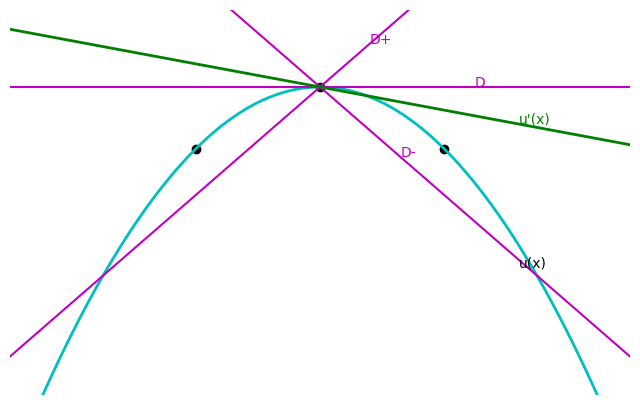

In [1]:
import numpy as np                  # Import library numpy untuk operasi numerik (array, linspace, dll)
import matplotlib.pyplot as plt     # Import matplotlib untuk membuat grafik/plot

# fungsi kurva u(x)
def u(x):
    return -0.2*(x-5)**2 + 4       # Fungsi parabola terbuka ke bawah, puncak di x=5, y=4

# domain kurva
x = np.linspace(0,10,400)          # Membuat 400 titik dari 0 sampai 10 (sumbu x)
y = u(x)                           # Menghitung nilai u(x) untuk setiap x

# tiga titik pada kurva
x1, x2, x3 = 3, 5, 7               # Menentukan tiga titik x
y1, y2, y3 = u(x1), u(x2), u(x3)   # Menghitung nilai y pada ketiga titik tersebut

# fungsi garis lurus
def line(x, x0, y0, m):
    return m*(x-x0) + y0           # Persamaan garis: y = m(x - x0) + y0

x_line = np.linspace(0,10,100)     # Domain untuk menggambar garis lurus

plt.figure(figsize=(8,5))          # Membuat figure dengan ukuran 8x5 inci

# kurva u(x)
plt.plot(x, y, 'c', linewidth=2)   # Plot kurva u(x) dengan warna cyan
plt.scatter([x1,x2,x3],[y1,y2,y3], color='black')  # Menandai tiga titik pada kurva

# garis magenta (D+, D, D-)
plt.plot(x_line, line(x_line,x2,y2,0.7), 'm')   # Garis dengan slope positif (D+)
plt.plot(x_line, line(x_line,x2,y2,0), 'm')     # Garis datar (D)
plt.plot(x_line, line(x_line,x2,y2,-0.7), 'm')  # Garis dengan slope negatif (D-)

# garis hijau u'(x)
plt.plot(x_line, line(x_line,x2,y2,-0.15), 'g', linewidth=2)  
# Garis ini merepresentasikan turunan (gradien sebenarnya di titik x=5)

# label
plt.text(5.8, line(5.8,x2,y2,0.7), "D+", color='m')     # Label D+
plt.text(7.5, line(7.5,x2,y2,0), "D", color='m')        # Label D
plt.text(6.3, line(6.3,x2,y2,-0.7), "D-", color='m')    # Label D-
plt.text(8.2, line(8.2,x2,y2,-0.15), "u'(x)", color='g')# Label turunan
plt.text(8.2, u(8.2)-0.3, "u(x)", color='k')            # Label kurva utama

plt.xlim(0,10)                   # Batas sumbu x dari 0 sampai 10
plt.ylim(0,5)                    # Batas sumbu y dari 0 sampai 5
plt.axis('off')                  # Menghilangkan tampilan sumbu (biar lebih clean)

plt.show()                       # Menampilkan grafik

Gambar tersebut menggambarkan konsep kemiringan garis terhadap suatu fungsi (u(x)) pada sebuah titik, yang sering digunakan dalam pembahasan turunan dan konsep subderivative / superderivative pada analisis atau Persamaan Diferensial Parsial (PDE).

### 1. Kurva $(u(x))$

Garis hitam melengkung adalah fungsi $(u(x))$.
Kurva ini menunjukkan bagaimana nilai fungsi berubah terhadap variabel $(x)$.

Tiga titik hitam adalah titik-titik tertentu pada kurva yang sedang dianalisis.

### 2. Garis biru $(u'(x))$

Garis biru menunjukkan garis singgung (tangent line) di titik tengah.

Kemiringan garis ini adalah turunan fungsi di titik tersebut:

$$
u'(x)
$$

Artinya:

* garis ini adalah kemiringan sebenarnya dari kurva pada titik itu.

### 3. Garis merah $(D^+), (D), dan (D^-)$

Garis merah menunjukkan kemungkinan kemiringan garis lain yang melewati titik tersebut.

* $(D^+)$ → garis dengan kemiringan lebih besar (lebih curam ke atas)
* $(D)$ → garis dengan kemiringan mendekati garis singgung
* $(D^-)$ → garis dengan kemiringan lebih kecil (lebih turun)

Secara konsep:

$$
D^- \leq u'(x) \leq D^+
$$

Artinya turunan fungsi berada di antara batas kemiringan atas dan bawah.

Intinya:

Turunan $(u'(x))$ adalah kemiringan garis singgung yang berada di antara berbagai kemungkinan garis lain yang melalui titik tersebut.

Jika $(\Delta x)$ tidak menuju nol (tetapi kecil), maka rumus-rumus ini menjadi aproksimasi turunan.

---

## Interpolating Polynomials (Polinom Interpolasi)

Salah satu cara menurunkan finite difference adalah dengan membuat polinom interpolasi melalui titik-titik stencil, lalu menurunkannya.

Misalkan kita punya (N+1) titik:
$$
(x_0, u(x_0)), (x_1, u(x_1)), \dots, (x_N, u(x_N))
$$

Polinom interpolasinya:
$$
P_N(x) = \sum_{i=0}^{N} u(x_i),\ell_i(x)
$$

di mana $(\ell_i(x))$ adalah polinom basis Lagrange.
$$
    \ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{x - x_0}{x_i - x_0} \frac{x - x_1}{x_i - x_1} \cdots \frac{x - x_{i-1}}{x_i - x_{i-1}}\frac{x - x_{i+1}}{x_i - x_{i+1}} \cdots \frac{x - x_{N}}{x_i - x_{N}}
$$

Sifat penting:

* $(\ell_i(x_i) = 1)$
* $(\ell_i(x_j) = 0) untuk (j \ne i)$

Karena kita tahu cara menurunkan polinom, kita bisa langsung mendapatkan finite difference dari sini.

### Contoh: Stencil 2 Titik

Misalkan kita punya dua titik: $x_0$ dan $x_1$.

Polinom interpolasi linear:

$$
P_1(x) = u(x_0)\frac{x - x_1}{x_0 - x_1} + u(x_1)\frac{x - x_0}{x_1 - x_0}
$$


#### Turunan Polinom

Turunkan terhadap $x$:

$$
P'_1(x) = u(x_0)\frac{d}{dx}\left(\frac{x - x_1}{x_0 - x_1}\right)

+ u(x_1)\frac{d}{dx}\left(\frac{x - x_0}{x_1 - x_0}\right)
  $$

Karena penyebut konstan:

$$
\frac{d}{dx}(x - x_1) = 1, \quad \frac{d}{dx}(x - x_0) = 1
$$

Maka:

$$
P'_1(x) = u(x_0)\frac{1}{x_0 - x_1} + u(x_1)\frac{1}{x_1 - x_0}
$$

#### Substitusi $\Delta x$

Definisikan:

$$
\Delta x = x_1 - x_0
$$

Sehingga:

$$
x_0 - x_1 = -\Delta x
$$

Substitusi:

$$
P'_1(x) = \frac{u(x_0)}{-\Delta x} + \frac{u(x_1)}{\Delta x}
$$

Gabungkan:

$$
P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}
$$

* Forward difference:
  $$
  D_+u(x_0) = \frac{u(x_1) - u(x_0)}{\Delta x}
  $$

* Backward difference:
  $$
  D_-u(x_1) = \frac{u(x_1) - u(x_0)}{\Delta x}
  $$


### Perluasan ke 3 Titik

Gunakan tiga titik: $x_0, x_1, x_2$

Polinom Lagrange orde 2:

$$
P_2(x) =
u(x_0)\frac{x - x_1}{x_0 - x_1}\frac{x - x_2}{x_0 - x_2}

+ u(x_1)\frac{x - x_0}{x_1 - x_0}\frac{x - x_2}{x_1 - x_2}
+ u(x_2)\frac{x - x_0}{x_2 - x_0}\frac{x - x_1}{x_2 - x_1}
  $$


#### Turunan

Gunakan aturan hasil kali:

$$
\frac{d}{dx}[f(x)g(x)] = f'(x)g(x) + f(x)g'(x)
$$

Contoh suku pertama:

$$
\frac{d}{dx}\left[(x-x_1)(x-x_2)\right]
= (x-x_2) + (x-x_1)
$$

Maka:

$$
\frac{d}{dx}\left[\frac{x-x_1}{x_0-x_1}\frac{x-x_2}{x_0-x_2}\right]
= \frac{1}{x_0-x_1}\frac{x-x_2}{x_0-x_2}

+ \frac{x-x_1}{x_0-x_1}\frac{1}{x_0-x_2}
  $$


#### Asumsi Grid Seragam

Gunakan:

$$
x_1 = x_0 + \Delta x, \quad x_2 = x_0 + 2\Delta x
$$

Sehingga:

$$
x_0 - x_1 = -\Delta x,\quad x_0 - x_2 = -2\Delta x
$$

$$
x_1 - x_2 = -\Delta x
$$


#### Substitusi ke Turunan

$$
P'_2(x) =
\frac{u(x_0)}{2\Delta x^2}(2x - x_1 - x_2)

+ \frac{u(x_1)}{-\Delta x^2}(2x - x_0 - x_2)
+ \frac{u(x_2)}{2\Delta x^2}(2x - x_0 - x_1)
  $$


#### Evaluasi di Titik Tengah ($x_1$)

Substitusi $x = x_1$:

$$
P'_2(x_1) =
\frac{u(x_0)}{2\Delta x^2}(2x_1 - x_1 - x_2)

+ \frac{u(x_1)}{-\Delta x^2}(2x_1 - x_0 - x_2)
+ \frac{u(x_2)}{2\Delta x^2}(2x_1 - x_0 - x_1)
  $$

Sederhanakan:

$$
= \frac{u(x_0)}{2\Delta x^2}(x_1 - x_2)

+ \frac{u(x_1)}{-\Delta x^2}(2x_1 - x_0 - x_2)
+ \frac{u(x_2)}{2\Delta x^2}(x_1 - x_0)
  $$


#### Gunakan hubungan grid

$$
x_1 - x_2 = -\Delta x
$$

$$
x_1 - x_0 = \Delta x
$$

$$
2x_1 - x_0 - x_2 = 0
$$

#### Hasil akhir

$$
P'_2(x_1)
= \frac{u(x_0)}{2\Delta x^2}(-\Delta x)

+ 0
+ \frac{u(x_2)}{2\Delta x^2}(\Delta x)
  $$

$$
P'_2(x_1)
= \frac{-u(x_0) + u(x_2)}{2\Delta x}
$$

$$
P'_2(x_1) = \frac{u(x_2) - u(x_0)}{2\Delta x}
$$

---


=== HASIL PERHITUNGAN TURUNAN ===
Analitik  : -0.0
Forward   : -0.019999999999997797
Backward  : 0.019999999999997797
Central   : 0.0


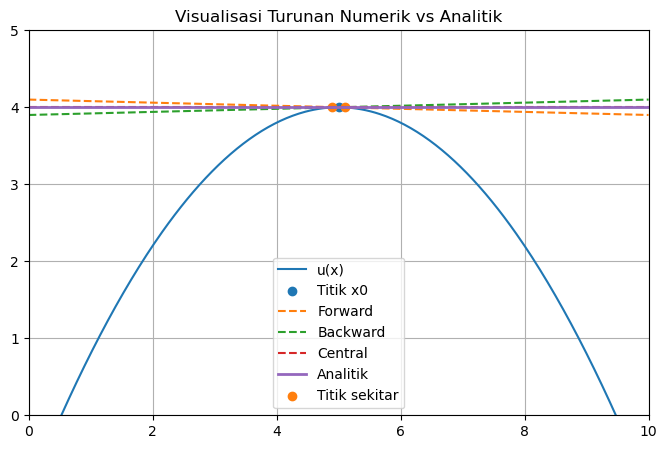

In [ ]:
import numpy as np              # Import numpy untuk perhitungan numerik (array, operasi matematika)
import matplotlib.pyplot as plt # Import matplotlib untuk membuat grafik/visualisasi

# DEFINISI FUNGSI
def u(x):
    return -0.2*(x - 5)**2 + 4   # Fungsi utama u(x), berbentuk parabola terbuka ke bawah

def du(x):
    return -0.4*(x - 5)          # Turunan analitik dari u(x)

# TITIK EVALUASI
x0 = 5       # Titik yang akan dihitung turunannya
dx = 0.1     # Selang kecil (Δx) untuk pendekatan numerik

x_minus = x0 - dx   # Titik di sebelah kiri (x0 - Δx)
x_plus  = x0 + dx   # Titik di sebelah kanan (x0 + Δx)

# METODE NUMERIK
D_plus = (u(x_plus) - u(x0)) / dx           # Forward Difference (pendekatan dari kanan)
D_minus = (u(x0) - u(x_minus)) / dx         # Backward Difference (pendekatan dari kiri)
D_central = (u(x_plus) - u(x_minus)) / (2*dx) # Central Difference (pendekatan dari kiri & kanan)

# ANALITIK
exact = du(x0)   # Nilai turunan sebenarnya di titik x0

# OUTPUT
print("=== HASIL PERHITUNGAN TURUNAN ===")  # Judul output
print("Analitik  :", exact)                 # Menampilkan nilai turunan sebenarnya
print("Forward   :", D_plus)                # Menampilkan hasil forward difference
print("Backward  :", D_minus)               # Menampilkan hasil backward difference
print("Central   :", D_central)             # Menampilkan hasil central difference

# VISUALISASI

x = np.linspace(0, 10, 400)   # Membuat 400 titik dari 0 sampai 10 untuk sumbu x
y = u(x)                      # Menghitung nilai u(x) untuk seluruh titik x

def line(x, x0, y0, m):
    return m*(x - x0) + y0    # Fungsi garis lurus: y = m(x - x0) + y0

x_line = np.linspace(0, 10, 100)  # Domain untuk menggambar garis-garis pendekatan

plt.figure(figsize=(8,5))   # Membuat kanvas gambar ukuran 8x5 inci

plt.plot(x, y, label="u(x)")  # Menggambar kurva utama u(x)
plt.scatter([x0], [u(x0)], label="Titik x0")  # Menandai titik evaluasi di kurva

plt.plot(x_line, line(x_line, x0, u(x0), D_plus), linestyle='--', label="Forward")   # Garis pendekatan forward
plt.plot(x_line, line(x_line, x0, u(x0), D_minus), linestyle='--', label="Backward") # Garis pendekatan backward
plt.plot(x_line, line(x_line, x0, u(x0), D_central), linestyle='--', label="Central")# Garis pendekatan central

plt.plot(x_line, line(x_line, x0, u(x0), exact), linewidth=2, label="Analitik") # Garis turunan sebenarnya (garis singgung)

plt.scatter([x_minus, x_plus], [u(x_minus), u(x_plus)], label="Titik sekitar") # Menandai titik kiri & kanan dari x0

plt.xlim(0,10)   # Mengatur batas sumbu x dari 0 sampai 10
plt.ylim(0,5)    # Mengatur batas sumbu y dari 0 sampai 5

plt.title("Visualisasi Turunan Numerik vs Analitik") # Judul grafik
plt.legend()   # Menampilkan legenda (keterangan garis)
plt.grid()     # Menampilkan grid agar grafik lebih mudah dibaca

plt.show()     # Menampilkan hasil grafik ke layar

## Taylor-Series Methods (Metode Deret Taylor)

Cara lain menurunkan finite difference adalah menggunakan deret Taylor dan metode koefisien tak tentu.

Ekspansi Taylor:

$$u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)$$

Misalkan kita ingin menurunkan pendekatan turunan pertama dengan akurasi orde dua seperti yang diperoleh sebelumnya. Pendekatan ini memerlukan nilai pada titik  
$(x_{n+1}, u(x_{n+1}))$ dan $(x_{n-1}, u(x_{n-1}))$.

Nilai-nilai tersebut dapat dinyatakan menggunakan deret Taylor sebagai berikut:

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n) + (x_{n+1}-x_n)u'(x_n) + \frac{(x_{n+1}-x_n)^2}{2!}u''(x_n) + \frac{(x_{n+1}-x_n)^3}{3!}u'''(x_n) + \mathcal{O}((x_{n+1}-x_n)^4) \\
&= u(x_n) + \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) + \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

dan

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n) + (x_{n-1}-x_n)u'(x_n) + \frac{(x_{n-1}-x_n)^2}{2!}u''(x_n) + \frac{(x_{n-1}-x_n)^3}{3!}u'''(x_n) + \mathcal{O}((x_{n-1}-x_n)^4) \\
&= u(x_n) - \Delta x\,u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) - \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

Sekarang, untuk membentuk ekspresi turunan, kita mengasumsikan pendekatan berikut

$$
u'(x_n) + R(x_n) = A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

dengan $R(x_n)$ adalah galat (error).

Dengan memasukkan ekspansi Taylor di atas diperoleh

$$
\begin{aligned}
u'(x_n) + R(x_n) &= A\left(u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) + \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)\right) \\
&+ B\,u(x_n) + C\left(u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!}u''(x_n) - \frac{\Delta x^3}{3!}u'''(x_n) + \mathcal{O}(\Delta x^4)\right)
\end{aligned}
$$

Karena kita menginginkan

$$
R(x_n) = \mathcal{O}(\Delta x^2)
$$

maka semua suku berorde lebih rendah harus hilang kecuali suku yang mengalikan $u'(x_n)$.

Dengan mengelompokkan suku-suku berdasarkan turunan yang sama diperoleh sistem persamaan

$$
\begin{aligned}
u(x_n): & \quad A + B + C = 0 \\
u'(x_n): & \quad A \Delta x - C \Delta x = 1 \\
u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 0
\end{aligned}
$$

Dari persamaan terakhir diperoleh

$$
A = -C
$$

Substitusi ke persamaan kedua menghasilkan

$$
A = \frac{1}{2\Delta x}, \qquad C = -\frac{1}{2\Delta x}
$$

Kemudian dari persamaan pertama diperoleh

$$
B = 0
$$

Sehingga pendekatan turunannya adalah

$$
u'(x_n) + R(x_n) =
\frac{u(x_{n+1}) - u(x_{n-1})}{2\Delta x}
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
+ \frac{1}{2\Delta x}\frac{\Delta x^3}{3!}u'''(x_n)
+ \mathcal{O}(\Delta x^4)
$$

Galatnya adalah

$$
R(x_n) =
\frac{\Delta x^2}{3!}u'''(x_n) + \mathcal{O}(\Delta x^3)
= \mathcal{O}(\Delta x^2)
$$

Artinya pendekatan ini memiliki **akurasi orde dua terhadap $\Delta x$**.

### Example: First Order Derivatives (Contoh: Turunan Orde Pertama)


Diberikan fungsi:
$$
f(x) = \sin(x), \quad f'(x) = \cos(x)
$$
$$
x_i = -2\pi + i\Delta x, \quad i = 0,1,2,\dots,19
$$

dengan:
$$
\Delta x = \frac{2\pi - (-2\pi)}{20-1} = \frac{4\pi}{19}
$$

Nilai numeriknya:
$$
\Delta x = 0.6613879270715355
$$

Rumus

$$f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}$$


Substitusi 

Karena $( f(x) = \sin(x) )$, maka:

$$
f'(x_i) \approx \frac{\sin(x_{i+1}) - \sin(x_i)}{\Delta x}
$$

Substitusi nilai Δx 

$$
f'(x_i) \approx \frac{\sin(x_i + 0.6613879270715355) - \sin(x_i)}{0.6613879270715355}
$$

$$
f'(x_0), f'(x_1), \dots, f'(x_{18})
$$

hitung dengan:
$$
f'(x_i) \approx \frac{\sin(x_{i+1}) - \sin(x_i)}{0.6613879270715355}
$$

$$
f'(x_{19}) \approx \frac{\sin(x_{19}) - \sin(x_{18})}{0.6613879270715355}
$$

Artinya hasil turunan berada di:
$$
x_i + \frac{\Delta x}{2}
$$

karena forward difference merepresentasikan nilai di tengah interval.

jadi:
$$
   \frac{\sin(x_i + 0.6613) - \sin(x_i)}{0.6613}
$$


berikut kode menghitung turunan fungsi sinus menggunakan finite difference, lalu membandingkan dengan turunan aslinya

delta_x = 0.6613879270715355


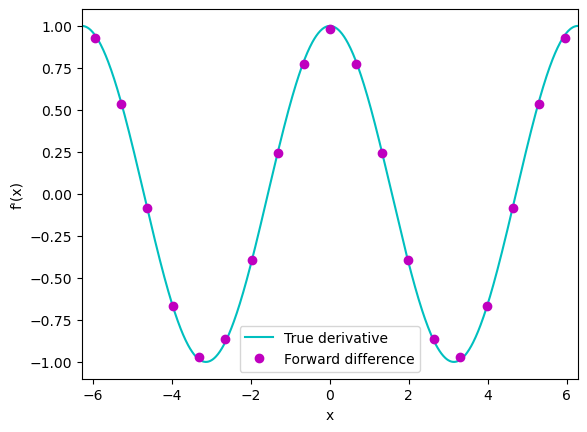

In [7]:
import numpy as np                      # Import numpy untuk operasi numerik (array, fungsi matematika)
import matplotlib.pyplot as plt         # Import matplotlib untuk membuat grafik

# Mendefinisikan fungsi dan turunan sebenarnya
f = lambda x: np.sin(x)                 # Fungsi f(x) = sin(x)
f_prime = lambda x: np.cos(x)           # Turunan analitik f'(x) = cos(x)

# Menggunakan diskretisasi seragam
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)   # Domain kontinu (halus) dari -2π sampai 2π (1000 titik)

N = 20                                         # Jumlah titik diskret (grid kasar)
x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)  # Titik-titik diskret untuk pendekatan numerik

delta_x = x_hat[1] - x_hat[0]                  # Menghitung jarak antar titik (Δx)
print("delta_x =", delta_x)                   # Menampilkan nilai Δx

# Menghitung turunan menggunakan metode forward difference dengan loop
f_prime_hat = np.empty(x_hat.shape)           # Menyediakan array kosong untuk menyimpan hasil turunan numerik

for i in range(N - 1):                        # Loop dari titik pertama sampai sebelum titik terakhir
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x  
    # Rumus forward difference:
    # f'(x) ≈ (f(x+Δx) - f(x)) / Δx

# Menggunakan backward difference untuk titik terakhir
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x  
# Karena tidak ada titik setelah titik terakhir, digunakan backward difference:
# f'(x) ≈ (f(x) - f(x-Δx)) / Δx

# Membuat grafik
fig = plt.figure()                           # Membuat objek figure (kanvas gambar)
axes = fig.add_subplot(1,1,1)                # Menambahkan 1 subplot (1 baris, 1 kolom, posisi ke-1)

# Turunan sebenarnya
axes.plot(x, f_prime(x), 'c', label="True derivative")  
# Plot turunan analitik (cos(x)) sebagai garis halus

# Turunan numerik hasil forward difference
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'mo', label="Forward difference")  
# Plot hasil numerik sebagai titik (marker 'o')
# x digeser 0.5Δx karena forward difference merepresentasikan nilai di tengah interval

axes.set_xlim((x[0], x[-1]))                 # Mengatur batas sumbu x
axes.set_ylim((-1.1, 1.1))                  # Mengatur batas sumbu y
axes.set_xlabel("x")                         # Label sumbu x
axes.set_ylabel("f'(x)")                     # Label sumbu y (turunan fungsi)
axes.legend()                                # Menampilkan legenda

plt.show()                                   # Menampilkan grafik ke layar

### Example: Second Order Derivative (Penurunan Rumus Turunan Kedua)

Kita ingin mencari pendekatan numerik untuk turunan kedua $u''(x_n)$ menggunakan tiga titik:
- $x_{n-1}$
- $x_n$
- $x_{n+1}$

dengan jarak grid seragam

$$
\Delta x = x_{n+1} - x_n = x_n - x_{n-1}
$$

Pendekatan ini diperoleh menggunakan ekspansi deret Taylor di sekitar titik $x_n$.

### 1. Ekspansi Taylor di sekitar $x_n$

Ekspansi Taylor untuk $u(x_{n+1})$:

$$
\begin{aligned}
u(x_{n+1}) &= u(x_n)
+ \Delta x\,u'(x_n)
+ \frac{\Delta x^2}{2}u''(x_n)
+ \frac{\Delta x^3}{6}u'''(x_n)
+ \frac{\Delta x^4}{24}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^5)
\end{aligned}
$$

Ekspansi Taylor untuk $u(x_{n-1})$:

$$
\begin{aligned}
u(x_{n-1}) &= u(x_n)
- \Delta x\,u'(x_n)
+ \frac{\Delta x^2}{2}u''(x_n)
- \frac{\Delta x^3}{6}u'''(x_n)
+ \frac{\Delta x^4}{24}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^5)
\end{aligned}
$$


### 2. Membentuk kombinasi linear

Kita asumsikan pendekatan turunan kedua memiliki bentuk

$$
u''(x_n) + R(x_n) =
A\,u(x_{n+1}) + B\,u(x_n) + C\,u(x_{n-1})
$$

dengan

- $A, B, C$ = koefisien yang ingin dicari  
- $R(x_n)$ = galat (error)


### 3. Substitusi ekspansi Taylor

Masukkan ekspansi Taylor ke dalam persamaan:

$$
\begin{aligned}
u''(x_n) + R(x_n)
&= A\Big[u(x_n)+\Delta x u'(x_n)+\frac{\Delta x^2}{2}u''(x_n)
+\frac{\Delta x^3}{6}u'''(x_n)+\frac{\Delta x^4}{24}u^{(4)}(x_n)\Big] \\
&+ B\,u(x_n) \\
&+ C\Big[u(x_n)-\Delta x u'(x_n)+\frac{\Delta x^2}{2}u''(x_n)
-\frac{\Delta x^3}{6}u'''(x_n)+\frac{\Delta x^4}{24}u^{(4)}(x_n)\Big]
\end{aligned}
$$


### 4. Mengelompokkan suku yang sama

Kelompokkan berdasarkan turunan:

Suku $u(x_n)$

$$
A + B + C
$$

Suku $u'(x_n)$

$$
A\Delta x - C\Delta x
$$

Suku $u''(x_n)$

$$
A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2}
$$


### 5. Menentukan syarat koefisien

Agar pendekatan menghasilkan $u''(x_n)$, maka:

(1) Suku $u(x_n)$ harus hilang

$$
A + B + C = 0
$$

(2) Suku $u'(x_n)$ harus hilang

$$
A\Delta x - C\Delta x = 0
$$

(3) Suku $u''(x_n)$ harus bernilai 1

$$
A\frac{\Delta x^2}{2} + C\frac{\Delta x^2}{2} = 1
$$


### 6. Menyelesaikan sistem persamaan

Dari persamaan kedua:

$$
A = C
$$

Masukkan ke persamaan ketiga:

$$
A\frac{\Delta x^2}{2} + A\frac{\Delta x^2}{2} = 1
$$

$$
A\Delta x^2 = 1
$$

$$
A = \frac{1}{\Delta x^2}
$$

Karena $A=C$, maka

$$
C = \frac{1}{\Delta x^2}
$$


### 7. Menentukan $B$

Gunakan persamaan pertama

$$
A + B + C = 0
$$

$$
\frac{1}{\Delta x^2} + B + \frac{1}{\Delta x^2} = 0
$$

$$
B = -\frac{2}{\Delta x^2}
$$


### 8. Memasukkan kembali ke rumus awal

Sehingga diperoleh

$$
u''(x_n) \approx
\frac{1}{\Delta x^2}u(x_{n+1})
-\frac{2}{\Delta x^2}u(x_n)
+\frac{1}{\Delta x^2}u(x_{n-1})
$$

atau

$$
u''(x_n) \approx
\frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
$$


### 9. Galat pendekatan

Jika suku orde lebih tinggi diperhitungkan, maka galatnya adalah

$$
R(x_n) =
\frac{\Delta x^2}{12}u^{(4)}(x_n)
+ \mathcal{O}(\Delta x^3)
$$

Rumus turunan kedua dengan finite difference central adalah

$$
u''(x_n) =
\frac{u(x_{n+1}) - 2u(x_n) + u(x_{n-1})}{\Delta x^2}
$$

dengan galat

$$
\mathcal{O}(\Delta x^2)
$$

Artinya metode ini memiliki akurasi orde dua (second-order accurate).

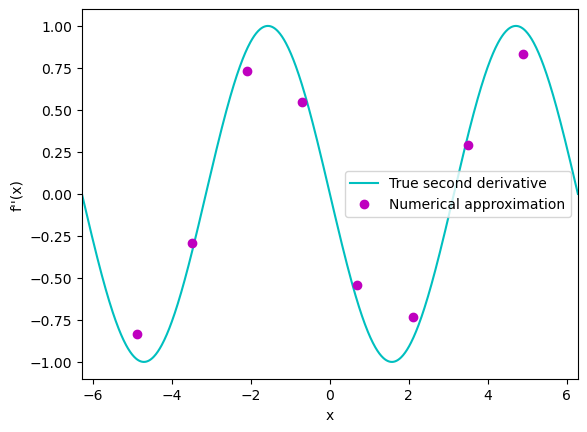

In [ ]:
import numpy as np                      # Import numpy untuk operasi numerik (array, fungsi matematika)
import matplotlib.pyplot as plt         # Import matplotlib untuk membuat grafik

# Mendefinisikan fungsi dan turunan keduanya yang sebenarnya
f = lambda x: np.sin(x)                 # Fungsi utama f(x) = sin(x)
f_dubl_prime = lambda x: -np.sin(x)     # Turunan kedua analitik f''(x) = -sin(x)

# Menggunakan diskretisasi seragam
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)   # Domain kontinu (halus) untuk referensi grafik

N = 10                                         # Jumlah titik diskret (grid kasar)
x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)  # Titik-titik diskret untuk pendekatan numerik

delta_x = x_hat[1] - x_hat[0]                  # Menghitung jarak antar titik (Δx)

# Menghitung pendekatan turunan kedua
f_dubl_prime_hat = np.empty(x_hat.shape)       # Menyediakan array kosong untuk hasil turunan numerik

# Central difference untuk titik tengah
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)
# Rumus central difference orde dua:
# f''(x) ≈ (f(x+Δx) - 2f(x) + f(x-Δx)) / Δx²
# Digunakan untuk semua titik kecuali ujung (boundary)

# Menggunakan formula khusus untuk titik di tepi domain
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / (delta_x**2)
# Forward difference orde dua untuk titik pertama (karena ti dak punya titik di kiri)

f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / (delta_x**2)
# Backward difference orde dua untuk titik terakhir (karena tidak punya titik di kanan)

# Membuat grafik
fig = plt.figure()                           # Membuat kanvas gambar
axes = fig.add_subplot(1,1,1)                # Menambahkan 1 subplot

# Turunan kedua sebenarnya
axes.plot(x, f_dubl_prime(x), 'c', label="True second derivative")
# Plot hasil analitik (halus)

# Hasil pendekatan numerik
axes.plot(x_hat, f_dubl_prime_hat, 'mo', label="Numerical approximation")
# Plot hasil numerik (titik-titik diskret)

axes.set_xlim((x[0], x[-1]))                 # Mengatur batas sumbu x
axes.set_ylim((-1.1, 1.1))                  # Mengatur batas sumbu y
axes.set_xlabel("x")                         # Label sumbu x
axes.set_ylabel("f''(x)")                    # Label sumbu y (turunan kedua)
axes.legend()                                # Menampilkan legenda

plt.show()                                   # Menampilkan grafik

# General Derivation (Penurunan Umum)

Untuk pendekatan finite difference secara umum, kita ingin menghitung turunan ke-$k$ dari suatu fungsi pada titik $\bar{x}$.

Misalkan kita memiliki stencil yang terdiri dari $N$ titik

$$
x_1, x_2, \ldots, x_N
$$

dengan syarat

$$
N \ge k + 1
$$

Artinya jumlah titik harus minimal satu lebih banyak dari orde turunan yang ingin dihitung.

Contoh:

* Turunan pertama ($k=1$) → minimal 2 titik
* Turunan kedua ($k=2$) → minimal 3 titik

Biasanya $\bar{x}$ adalah salah satu titik stencil, tetapi ini tidak wajib.
Kita juga mengasumsikan bahwa fungsi $u(x)$ cukup halus (smooth) sehingga ekspansi Taylor berlaku.


### 1. Ekspansi Taylor pada setiap titik stencil

Pada setiap titik $x_i$ kita dapat menuliskan ekspansi Taylor di sekitar $\bar{x}$

$$
u(x_i) =
u(\bar{x})

+ (x_i-\bar{x})u'(\bar{x})
+ \frac{(x_i-\bar{x})^2}{2!}u''(\bar{x})
+ \cdots
+ \frac{(x_i-\bar{x})^k}{k!}u^{(k)}(\bar{x})
+ \cdots
  $$

Artinya nilai fungsi di titik $x_i$ dapat ditulis sebagai kombinasi dari:

* nilai fungsi di $\bar{x}$
* turunan pertama
* turunan kedua
* turunan yang lebih tinggi

Ini adalah langkah dasar dari seluruh metode finite difference.

### 2. Membentuk kombinasi linear

Kita ingin membentuk kombinasi linear dari nilai fungsi pada titik stencil

$$
a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_N u(x_N)
$$

Tujuannya adalah agar kombinasi ini menghasilkan turunan ke-$k$:

$$
u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p)

a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_N u(x_N)
$$

dengan

* $a_i$ = koefisien finite difference
* $\mathcal{O}(\Delta x^p)$ = galat metode
* $p$ = orde akurasi metode


### 3. Mengganti dengan ekspansi Taylor

Jika ekspansi Taylor pada langkah sebelumnya kita substitusi ke dalam kombinasi linear, kita memperoleh

$$
\sum_{j=1}^{N} a_j u(x_j)
$$

menjadi

$$

\left(\sum_{j=1}^{N} a_j \right)u(\bar{x})
+
\left(\sum_{j=1}^{N} a_j(x_j-\bar{x})\right)u'(\bar{x})
$$

$$
+
\left(\sum_{j=1}^{N} a_j\frac{(x_j-\bar{x})^2}{2!}\right)u''(\bar{x})

* \cdots
$$

Artinya kombinasi linear tersebut sebenarnya merupakan kombinasi dari berbagai turunan.

Padahal yang kita inginkan hanya turunan ke-$k$.

Agar pendekatan menghasilkan turunan ke-$k$, kita harus:

1. Menghilangkan semua turunan yang lebih rendah dari $k$
2. Menyisakan hanya turunan ke-$k$

Artinya koefisien harus memenuhi kondisi tertentu.


### 4. Kondisi matematis untuk koefisien

Syaratnya adalah

$$
\frac{1}{(i - 1)!}
\sum_{j=1}^{N}
a_j (x_j - \bar{x})^{(i-1)}

\begin{cases}
1, & \text{jika } i - 1 = k \
0, & \text{lainnya}
\end{cases}
$$

untuk

$$
i = 1,2,\ldots,N
$$

Persamaan ini berasal dari menyamakan koefisien pada ekspansi Taylor, yang berfungsi untuk:

### Menghilangkan nilai fungsi

Untuk $i=1$

$$
\sum a_j = 0
$$

Ini menghilangkan suku

$$
u(\bar{x})
$$


### Menghilangkan turunan pertama

Untuk $i=2$

$$
\sum a_j(x_j-\bar{x}) = 0
$$

Ini menghilangkan

$$
u'(\bar{x})
$$


### Menghilangkan turunan kedua

Untuk $i=3$

$$
\sum a_j(x_j-\bar{x})^2 = 0
$$

Ini menghilangkan

$$
u''(\bar{x})
$$


### Menyisakan turunan ke-$k$

Ketika

$$
i-1 = k
$$

maka

$$
\frac{1}{k!}\sum a_j(x_j-\bar{x})^k = 1
$$

Sehingga suku yang tersisa adalah

$$
u^{(k)}(\bar{x})
$$


### 5. Sistem persamaan yang terbentuk

Semua kondisi tersebut membentuk sistem persamaan linear

untuk koefisien

$$
a_1,a_2,\ldots,a_N
$$

yang dapat ditulis dalam bentuk matriks:

$$
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1 \\
(x_1 - \bar{x}) & (x_2 - \bar{x}) & (x_3 - \bar{x}) & \cdots & (x_N - \bar{x}) \\
(x_1 - \bar{x})^2 & (x_2 - \bar{x})^2 & (x_3 - \bar{x})^2 & \cdots & (x_N - \bar{x})^2 \\
\vdots & \vdots & \vdots & \ddots & \vdots
\end{bmatrix}
\begin{bmatrix}
a_1 \\ a_2 \\ a_3 \\ \vdots \\ a_N
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 1 \\ \vdots \\ 0
\end{bmatrix}
$$

### 6. Hubungan dengan Matriks Vandermonde

Matriks di sisi kiri memiliki bentuk khusus yang disebut Vandermonde matrix.

Jika semua titik

$$
x_1,x_2,\ldots,x_N
$$

berbeda, maka matriks ini memiliki solusi unik.

Artinya koefisien finite difference

$$
a_1,a_2,\ldots,a_N
$$

dapat dihitung secara unik.

### 7. Hubungan dengan rumus finite difference yang umum

Dari metode umum ini muncul rumus-rumus yang sering digunakan.

### Turunan pertama (central difference)

$$
u'(x_n) \approx
\frac{u(x_{n+1})-u(x_{n-1})}{2\Delta x}
$$

### Turunan kedua

$$
u''(x_n) \approx
\frac{u(x_{n+1})-2u(x_n)+u(x_{n-1})}{\Delta x^2}
$$

Semua rumus tersebut adalah kasus khusus dari derivasi umum finite difference.

Aproksimasi : 0.8414709848078965
Analitik    : 1.0


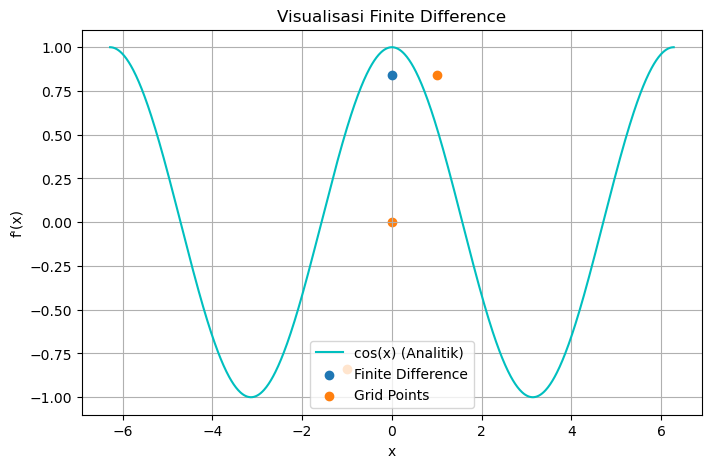

In [14]:
import numpy as np                  # Import numpy untuk operasi numerik (array, aljabar linear)
import matplotlib.pyplot as plt     # Import matplotlib untuk visualisasi grafik
import scipy.special                # Import fungsi khusus (untuk faktorial)

# FUNGSI FINITE DIFFERENCE
def finite_difference(k, x_bar, x):
    N = x.shape[0]                 # Menentukan jumlah titik grid (banyak data dalam x)

    A = np.ones((N, N))            # Membuat matriks NxN berisi 1 (akan diisi matriks Taylor)

    x_row = x - x_bar              # Menggeser semua titik terhadap titik pusat x_bar

    for i in range(1, N):          
        A[i, :] = x_row ** i / scipy.special.factorial(i)  
        # Mengisi baris ke-i dengan (x - x_bar)^i / i!
        # Ini membentuk sistem dari deret Taylor

    b = np.zeros(N)                # Membuat vektor nol sepanjang N
    b[k] = 1.0                     # Mengisi posisi ke-k dengan 1 (target turunan ke-k)

    c = np.linalg.solve(A, b)      # Menyelesaikan sistem linear A*c = b
                                  # Hasilnya adalah koefisien finite difference

    return c                       # Mengembalikan koefisien

# FUNGSI UJI
f = lambda x: np.sin(x)            # Fungsi utama f(x) = sin(x)
f_true = lambda x: np.cos(x)       # Turunan analitik f'(x) = cos(x)

# GRID
x = np.linspace(-2*np.pi, 2*np.pi, 1000)  
# Membuat domain halus untuk grafik (referensi)

x_nodes = np.array([-1.0, 0.0, 1.0])  
# Titik grid diskret untuk metode finite difference

# Koefisien FD turunan pertama
c = finite_difference(1, 0.0, x_nodes)  
# Menghitung koefisien turunan pertama di x_bar = 0

# Hitung aproksimasi di x=0
approx = sum(c[i] * f(x_nodes[i]) for i in range(len(c)))  
# Menghitung turunan numerik sebagai kombinasi linear:
# f'(x) ≈ Σ c_i * f(x_i)

print("Aproksimasi :", approx)     # Menampilkan hasil numerik
print("Analitik    :", f_true(0))  # Menampilkan nilai sebenarnya

# VISUALISASI
plt.figure(figsize=(8,5))          # Membuat kanvas grafik ukuran 8x5

plt.plot(x, f_true(x), color='c',label="cos(x) (Analitik)")  
# Menggambar kurva turunan sebenarnya

plt.scatter(0, approx, label="Finite Difference", zorder=3)  
# Menampilkan titik hasil aproksimasi di x=0

plt.scatter(x_nodes, f(x_nodes), label="Grid Points")  
# Menampilkan titik-titik grid yang digunakan dalam perhitungan

plt.title("Visualisasi Finite Difference")  # Judul grafik
plt.xlabel("x")                             # Label sumbu x
plt.ylabel("f'(x)")                         # Label sumbu y

plt.legend()                                # Menampilkan legenda
plt.grid()                                  # Menampilkan grid

plt.show()                                  # Menampilkan grafik ke layar

# Error Analysis (Analisis Galat)

Teorema Lagrange bahwa suku sisa (*remainder term*) dari interpolasi polinomial memiliki bentuk

$$
R_N(x) = (x - x_0)(x - x_1)\cdots (x - x_{N})(x - x_{N+1}) \frac{u^{(N+1)}(c)}{(N+1)!}
$$

dengan syarat bahwa fungsi

$$
u(x) \in C^{N+1}
$$

pada interval yang kita perhatikan.

Artinya fungsi $u(x)$ harus memiliki turunan kontinu hingga orde $N+1$ agar ekspansi ini valid.


## Turunan dari polinomial interpolasi

Jika kita mengambil turunan dari polinomial interpolasi $P_N(x)$ (yang ditulis menggunakan polinom Newton), maka diperoleh

$$\begin{aligned}
    P_N'(x) &= [u(x_0), u(x_1)] + ((x - x_1) + (x - x_0)) [u(x_0), u(x_1), u(x_2)]+ \cdots \\
    &\quad  + \left(\sum^{N-1}_{i=0}\left( \prod^{N-1}_{j=0,~j\neq i} (x - x_j) \right )\right ) [u(x_0), u(x_1), \ldots, u(x_N)]
\end{aligned}$$


di mana

* $[u(x_0),u(x_1)]$ adalah divided difference
* $[u(x_0),u(x_1),u(x_2)]$ adalah divided difference orde lebih tinggi

Divided difference adalah cara untuk membangun polinom interpolasi Newton.


## Turunan dari suku sisa (remainder)

Secara serupa, kita juga dapat menghitung turunan dari suku sisa

$$
R_N(x)
$$

yang menghasilkan

$$R_N'(x) = \left(\sum^{N}_{i=0} \left( \prod^{N}_{j=0,~j\neq i} (x - x_j) \right )\right ) \frac{u^{(N+1)}(c)}{(N+1)!}$$

Persamaan ini menunjukkan bagaimana kesalahan (error) dari interpolasi berubah ketika kita menghitung turunan.


## Aproksimasi turunan pada titik data

Sekarang jika kita menghitung turunan pada salah satu titik data

$$
(x_k, y_k)
$$

maka persamaan sebelumnya menjadi lebih sederhana

$$
u'(x_k) = P_N'(x_k) + R_N'(x_k)
$$

Artinya:

* $P_N'(x_k)$ → turunan dari polinom interpolasi (aproksimasi numerik)
* $R_N'(x_k)$ → galat dari aproksimasi tersebut


## Perkiraan besar galat

Jika kita mendefinisikan

$$
\Delta x = \max_i |x_k - x_i|
$$

yaitu jarak maksimum antara titik evaluasi dan titik stencil, maka suku galat memenuhi

$$
R_N'(x_k) = \mathcal{O}(\Delta x^N)
$$

ketika

$$
\Delta x \rightarrow 0
$$


Hasil ini menunjukkan bahwa:

* metode finite difference akan konvergen
* semakin kecil $\Delta x$, semakin kecil galatnya
* dengan menambah jumlah titik stencil, kita dapat memperoleh aproksimasi dengan orde yang lebih tinggi

Dengan kata lain, kita bisa membuat aproksimasi turunan dengan akurasi setinggi yang kita inginkan.

Analisis galat ini menjelaskan bahwa:

1. Turunan numerik sebenarnya berasal dari turunan polinom interpolasi
2. Perbedaan antara turunan sebenarnya dan aproksimasi berasal dari remainder interpolation
3. Galatnya berorde

$$
\mathcal{O}(\Delta x^N)
$$

yang berarti metode menjadi semakin akurat ketika grid semakin halus.

### Galat Pemotongan

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk menemukan *galat pemotongan*.

Sebagai contoh, mari kita pertimbangkan lagi aproksimasi turunan pertama di atas, kita memerlukan ekspansi Taylor
$$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$
dan
$$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

Memasukkan ini ke dalam ekspresi kita, kita dapatkan
$$\begin{aligned}
    D_+ u(\bar{x}) &= \frac{u(\bar{x} + \Delta x) - u(\bar{x})}{\Delta x} \\
    &= \frac{\Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)}{\Delta x} \\
    &= u'(\bar{x}) + \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3).
\end{aligned}$$

Jika kita hitung $D_+ u(\bar{x}) - u'(\bar{x})$, galat pemotongan:

$$
\frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3)
$$

Galat $D_+$: $\mathcal{O}(\Delta x)$, dikontrol oleh $u''(\bar{x})$.

Untuk central difference $D_0 u(\bar{x}) - u'(\bar{x})$:

$$
\frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Galat $D_0$: $\mathcal{O}(\Delta x^2)$, dikontrol oleh $u'''(\bar{x})$.

Perbandingan: $D_0$ lebih akurat dari $D_+$ karena orde galat lebih tinggi.

Untuk turunan kedua, galat central:

$$
\frac{\Delta x^2}{12} u^{(4)}(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Kesimpulan: Finite differences konvergen dengan $\mathcal{O}(\Delta x^p)$, p meningkat dengan titik stencil.

Dari ekspansi Taylor untuk $u(\bar{x} + \Delta x)$ dan $u(\bar{x} - \Delta x)$, substitusi ke $D_0 u(\bar{x}) = \frac{u(\bar{x} + \Delta x) - u(\bar{x} - \Delta x)}{2\Delta x}$ menghasilkan:

$$
D_0 u(\bar{x}) = u'(\bar{x}) + \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

Sehingga galat truncation:

$$
D_0 u(\bar{x}) - u'(\bar{x}) = \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$

### Derivasi Model Galat untuk Orde Akurasi Grafik

Asumsikan galat truncation $e(\Delta x) = C \Delta x^n$, di mana $n$ adalah orde akurasi.

Ambil logaritma natural:

$$
\log e(\Delta x) = \log C + n \log \Delta x
$$

Ini adalah persamaan garis lurus $y = m x + b$, dengan:

- $y = \log e(\Delta x)$
- $x = \log \Delta x$
- Kemiringan $m = n$ (orde akurasi)
- Intersep $b = \log C$

Untuk menentukan $C$ dari titik pertama $(\Delta x_1, e_1)$:

$$
\log C = \log e_1 - n \log \Delta x_1
$$

$$
C = e^{\log e_1 - n \log \Delta x_1} = \frac{e_1}{(\Delta x_1)^n}
$$

Dengan plot $\log e$ vs $\log \Delta x$, kemiringan memberikan $n$, memungkinkan verifikasi empiris orde konvergensi metode finite difference.

### Galat Pemotongan

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk menemukan *galat pemotongan*.

Sebagai contoh, mari kita pertimbangkan lagi aproksimasi turunan pertama di atas, kita memerlukan ekspansi Taylor
$$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$
dan
$$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

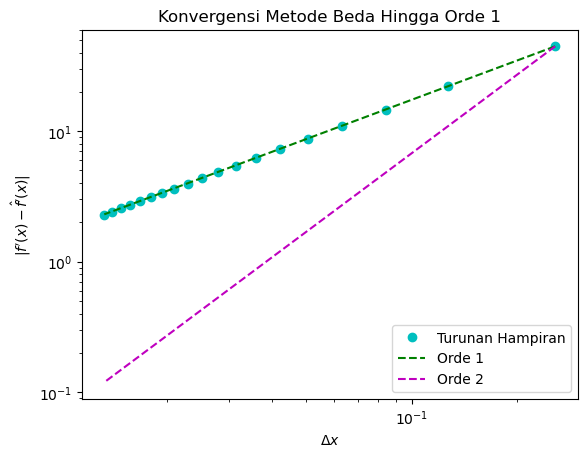

In [15]:
import numpy as np                      # Import numpy untuk operasi numerik (array, norm, log, dll)
import matplotlib.pyplot as plt         # Import matplotlib untuk membuat grafik

f = lambda x: np.sin(x) + x**2 + 3.0 * x**3  
# Fungsi utama f(x) = sin(x) + x² + 3x³

f_prime = lambda x: np.cos(x) + 2.0 * x + 9.0 * x**2  
# Turunan analitik f'(x)

delta_x = []   # List untuk menyimpan nilai Δx (jarak grid)
error = []     # List untuk menyimpan error maksimum

for N in range(50, 1000, 50):  
    # Loop jumlah grid dari 50 sampai 950 (step 50)

    x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N)  
    # Membuat grid diskret sebanyak N titik

    delta_x.append(x_hat[1] - x_hat[0])  
    # Menyimpan jarak antar titik (Δx)

    f_prime_hat = np.empty(x_hat.shape)  
    # Menyediakan array kosong untuk hasil turunan numerik

    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / delta_x[-1]  
    # Forward difference untuk semua titik kecuali terakhir:
    # f'(x) ≈ (f(x+Δx) - f(x)) / Δx

    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]  
    # Backward difference untuk titik terakhir

    error.append(np.linalg.norm(np.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat), ord=np.inf))  
    # Menghitung error maksimum (norm infinity):
    # |f'(x) - f'_numerik|

error = np.array(error)        # Mengubah list error menjadi array numpy
delta_x = np.array(delta_x)    # Mengubah list Δx menjadi array numpy

fig = plt.figure()             # Membuat figure (kanvas)
axes = fig.add_subplot(1,1,1)  # Menambahkan subplot tunggal

axes.loglog(delta_x, error, 'co', label="Turunan Hampiran")  
# Plot error vs Δx dalam skala log-log (warna cyan, marker bulat)

order_C = lambda delta_x, error, order: np.exp(np.log(error) - order*np.log(delta_x))  
# Fungsi untuk menghitung konstanta C pada hubungan:
# error ≈ C * (Δx)^order

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'g--', label="Orde 1")  
# Garis referensi orde 1 (kemiringan slope = 1)

axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'm--', label="Orde 2")  
# Garis referensi orde 2 (kemiringan slope = 2)

axes.legend(loc=4)  
# Menampilkan legenda di pojok kanan bawah

axes.set_title("Konvergensi Metode Beda Hingga Orde 1")  
# Judul grafik

axes.set_xlabel(r"$\Delta x$")  
# Label sumbu x (Δx, pakai format LaTeX)

axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")  
# Label sumbu y (error turunan)

plt.show()  
# Menampilkan grafik

In [23]:
import numpy as np
import scipy.special as sp

def finite_difference(k, x_bar, x):
    """Menghitung koefisien finite difference turunan ke-k"""

    N = x.shape[0]              # jumlah titik grid
    A = np.ones((N, N))         # matriks Taylor (awal semua 1)
    x_row = x - x_bar           # selisih titik terhadap pusat

    for i in range(1, N):
        A[i, :] = x_row**i / sp.factorial(i)   # isi matriks Taylor

    b = np.zeros(N)             # vektor target
    b[k] = 1.0                  # pilih turunan ke-k

    c = np.linalg.solve(A, b)   # selesaikan sistem A*c = b
    return c                    # hasil koefisien


# OUTPUT 

display(finite_difference(2, 0.0, np.array([-1.0, 0.0, 1.0])))
# turunan ke-2 (central difference)

display(finite_difference(1, 0.0, np.array([-1.0, 0.0, 1.0])))
# turunan ke-1 (central difference)

display(finite_difference(1, -2.0, np.array([-2.0, -1.0, 0.0, 1.0, 2.0])))
# turunan ke-1 di titik tidak simetris

display(finite_difference(2, 0.0, np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)
# turunan ke-2 dengan grid tidak simetris

array([ 1., -2.,  1.])

array([-0.5,  0. ,  0.5])

array([-2.08333333,  4.        , -3.        ,  1.33333333, -0.25      ])

array([ 10., -15.,  -4.,  14.,  -6.,   1.])

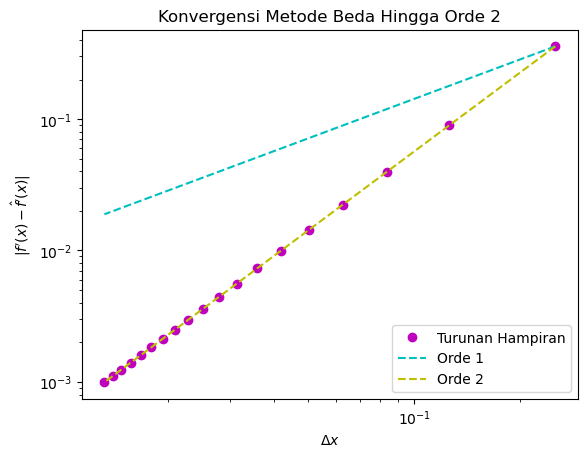

In [17]:
import numpy as np                      # Import numpy untuk operasi numerik (array, norm, log, dll)
import matplotlib.pyplot as plt         # Import matplotlib untuk membuat grafik

f = lambda x: np.sin(x) + x**2 + 3.0 * x**3  
# Fungsi utama f(x)

f_prime = lambda x: np.cos(x) + 2.0 * x + 9.0 * x**2  
# Turunan analitik f'(x)

delta_x = []   # List untuk menyimpan nilai Δx
error = []     # List untuk menyimpan error maksimum

for N in range(50, 1000, 50):  
    # Loop jumlah grid dari 50 sampai 950

    x_hat = np.linspace(-2 * np.pi, 2 * np.pi, N + 1)  
    # Membuat grid dengan N+1 titik (agar interval terbagi N bagian)

    delta_x.append(x_hat[1] - x_hat[0])  
    # Menyimpan jarak antar titik (Δx)

    # menghitung turunan numerik
    f_prime_hat = np.empty(x_hat.shape)  
    # Menyediakan array kosong untuk hasil turunan numerik

    # central difference (orde 2)
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])  
    # Rumus central difference:
    # f'(x) ≈ (f(x+Δx) - f(x-Δx)) / (2Δx)
    # Berlaku untuk titik tengah (bukan boundary)

    # second-order difference di batas
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])  
    # Forward difference orde 2 untuk titik pertama

    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])  
    # Backward difference orde 2 untuk titik terakhir

    error.append(np.linalg.norm(np.abs(f_prime(x_hat) - f_prime_hat), ord=np.inf))  
    # Menghitung error maksimum (norm infinity)

error = np.array(error)        # Mengubah list error menjadi array numpy
delta_x = np.array(delta_x)    # Mengubah list Δx menjadi array numpy

fig = plt.figure()             # Membuat figure
axes = fig.add_subplot(1,1,1)  # Membuat subplot tunggal

axes.loglog(delta_x, error, "mo", label="Turunan Hampiran")  
# Plot error vs Δx dalam skala log-log (warna kuning, marker bulat)

order_C = lambda delta_x, error, order: np.exp(np.log(error) - order*np.log(delta_x))  
# Menghitung konstanta C pada hubungan error ≈ C(Δx)^order

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'c--', label="Orde 1")  
# Garis referensi orde 1

axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'y--', label="Orde 2")  
# Garis referensi orde 2

axes.legend(loc=4)  
# Menampilkan legenda di kanan bawah

axes.set_title("Konvergensi Metode Beda Hingga Orde 2")  
# Judul grafik

axes.set_xlabel(r"$\Delta x$")  
# Label sumbu x (Δx)

axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")  
# Label sumbu y (error)

plt.show()  
# Menampilkan grafik